In [54]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.dates as mdates

from db_config import get_database_url
from sqlalchemy import create_engine


In [22]:
engine = create_engine(get_database_url())
df = pd.read_sql(
    "SELECT * FROM public.pollen_by_date_time",
    engine
)

df.head()

,fdate,ftime,camps_point_id,analysis_time,alder_pollen,birch_pollen,grass_pollen,mugwort_pollen,olive_pollen,ragweed_pollen,pollen_total
0,2026-07-10,04:00:00,11,2026-07-10,0.0000000000,0.0010986328,11.6041870117,0.0973815918,0.0000000000,0.0000000000,11.7026672363
1,2026-07-10,23:00:00,15,2026-07-10,0.0000023842,0.0013732910,9.4904174805,0.1492156982,0.0000000000,0.0000000000,9.6410083771
2,2026-07-10,23:00:00,14,2026-07-10,0.0000023842,0.0014495850,9.2128295898,0.3449249268,0.0000000000,0.0000000000,9.5592060089
3,2026-07-10,23:00:00,13,2026-07-10,0.0000023842,0.0014572144,8.8378295898,0.3645019531,0.0000000000,0.0000000000,9.2037906647
4,2026-07-10,23:00:00,12,2026-07-10,0.0000019073,0.0013427734,8.9034576416,0.1936492920,0.0000000000,0.0000000000,9.0984516144


In [10]:
df['fdate'] = pd.to_datetime(df['fdate'], format='%Y-%m-%d')
df['ftime'] = pd.to_datetime(df['ftime'], format='%H:%M:%S').dt.time
df['analysis_time'] = pd.to_datetime(df['analysis_time'], format='%Y-%m-%d')
df.head()

,fdate,ftime,camps_point_id,analysis_time,alder_pollen,birch_pollen,grass_pollen,mugwort_pollen,olive_pollen,ragweed_pollen,pollen_total
0,2026-07-10,16:00:00,8,2026-07-10,0.0000081062,0.0011901855,10.8042297363,0.4518356323,0.0000000000,0.0000000000,11.2572631836
1,2026-07-10,16:00:00,7,2026-07-10,0.0000104904,0.0015258789,12.0647277832,0.2766723633,0.0000000000,0.0000000000,12.3429365158
2,2026-07-10,16:00:00,6,2026-07-10,0.0000059605,0.0016479492,14.3647460938,0.2292327881,0.0000000000,0.0000000000,14.5956325531
3,2026-07-10,16:00:00,5,2026-07-10,0.0000038147,0.0010261536,7.3604736328,0.0817871094,0.0000000000,0.0000000000,7.4432907104
4,2026-07-10,16:00:00,4,2026-07-10,0.0000038147,0.0012512207,9.1240234375,0.1535987854,0.0000000000,0.0000000000,9.2788772583


In [11]:
df.dtypes

fdate             datetime64[s]
ftime                    object
camps_point_id            int64
analysis_time     datetime64[s]
alder_pollen            float64
birch_pollen            float64
grass_pollen            float64
mugwort_pollen          float64
olive_pollen            float64
ragweed_pollen          float64
pollen_total            float64
dtype: object

In [5]:
pd.set_option('display.float_format', '{:.10f}'.format)

In [16]:
df_grouped = df.groupby(['fdate', 'camps_point_id'])[
    ['alder_pollen', 'birch_pollen', 'grass_pollen', 'mugwort_pollen', 'olive_pollen', 'ragweed_pollen', 'pollen_total']
].mean()
df_grouped.tail(20)

alder_pollen  birch_pollen  grass_pollen  \
fdate      camps_point_id                                             
2026-07-09 11              0.0000042949  0.0072127978 18.5580717723   
           12              0.0000049463  0.0072582563 16.9164276123   
           13              0.0000041307  0.0072801908 15.2381515503   
           14              0.0000047960  0.0073494911 14.4379851023   
           15              0.0000039156  0.0073157946 15.1043020884   
2026-07-10 1               0.0000340765  0.0013339520 13.7178408305   
           2               0.0000303214  0.0012860298 13.5422286987   
           3               0.0000075524  0.0012207826 13.6238110860   
           4               0.0000079200  0.0011899471 13.9898351034   
           5               0.0000082180  0.0011327267 13.7690709432   
           6               0.0000054464  0.0014349620 13.1054827372   
           7               0.0000250166  0.0014330546 12.8799985250   
           8               0.0000053470  0.0014092127 12.0290978750   
           9               0.0000063702  0.0013127327 11.8538761139   
           10              0.0000061418  0.0012760162 12.3430360158   
           11              0.0000099428  0.0016271273 14.0312773387   
           12              0.0000293590  0.0014627775 13.4969120026   
           13              0.0000098385  0.0014853477 12.8754609426   
           14              0.0000304319  0.0014575322 12.5264867147   
           15              0.0000087010  0.0014095306 13.2215766907   

                           mugwort_pollen  olive_pollen  ragweed_pollen  \
fdate      camps_point_id                                                 
2026-07-09 11                0.1528547605  0.0000007947    0.0000000000   
           12                0.2183119456  0.0000006358    0.0000000000   
           13                0.3166832924  0.0000006358    0.0000000000   
           14                0.3186006546  0.0000006358    0.0000000000   
           15                0.2263998985  0.0000006358    0.0000000000   
2026-07-10 1                 0.2322279612  0.0000000000    0.0000000000   
           2                 0.2136268616  0.0000000000    0.0000000000   
           3                 0.2856858571  0.0000000000    0.0000000000   
           4                 0.3319277763  0.0000000000    0.0000000000   
           5                 0.2315546672  0.0000000000    0.0000000000   
           6                 0.2497914632  0.0000006358    0.0000000000   
           7                 0.3287569682  0.0000006358    0.0000000000   
           8                 0.9802398682  0.0000006358    0.0000000000   
           9                 0.9397665660  0.0000006358    0.0000000000   
           10                0.6490770976  0.0000000000    0.0000000000   
           11                0.1205113729  0.0000006358    0.0000000000   
           12                0.2238852183  0.0000006358    0.0000000000   
           13                0.3412567774  0.0000006358    0.0000000000   
           14                0.3107935588  0.0000006358    0.0000000000   
           15                0.1836210887  0.0000006358    0.0000000000   

                           pollen_total  
fdate      camps_point_id                
2026-07-09 11             18.7181441685  
           12             17.1420032978  
           13             15.5621197422  
           14             14.7639406721  
           15             15.3380223612  
2026-07-10 1              13.9514367580  
           2              13.7571717898  
           3              13.9107252359  
           4              14.3229606549  
           5              14.0017665625  
           6              13.3567152023  
           7              13.2102141976  
           8              13.0107529561  
           9              12.7949623664  
           10             12.9933953285  
           11             14.1534264882  
           12             13.7222899795  
           13  

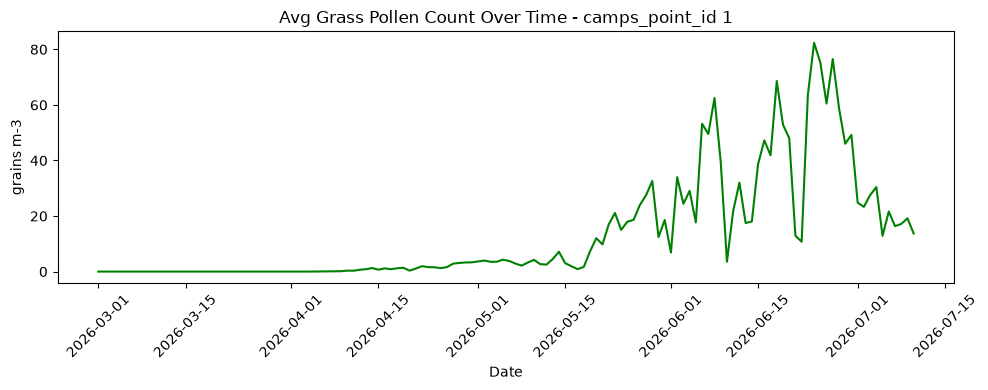

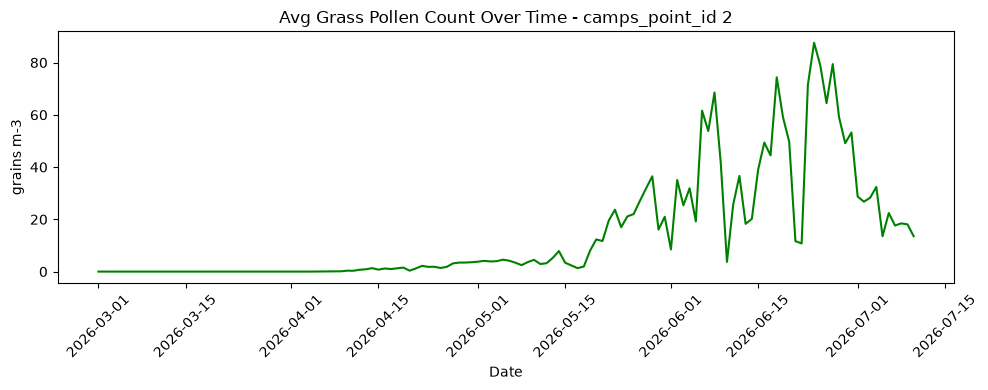

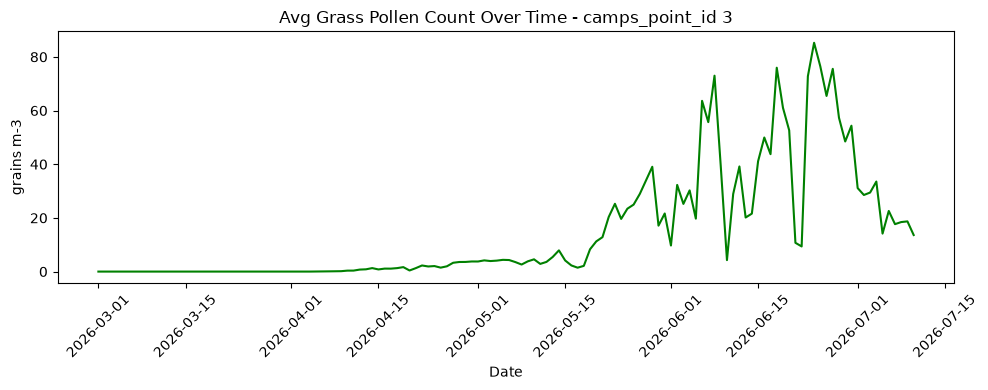

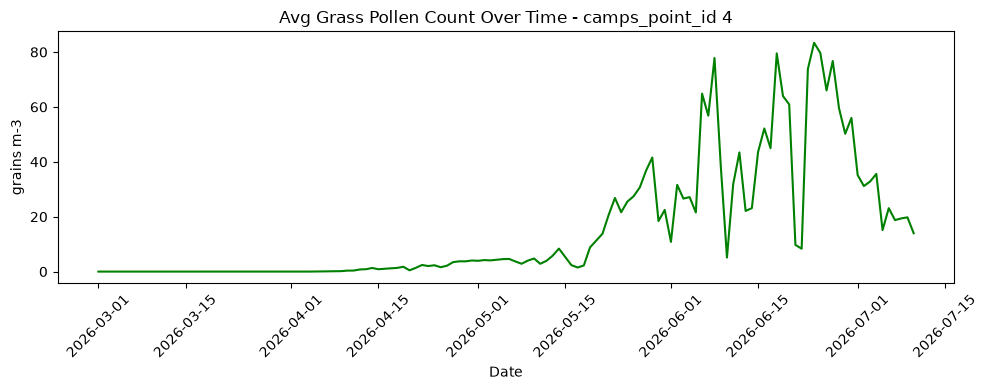

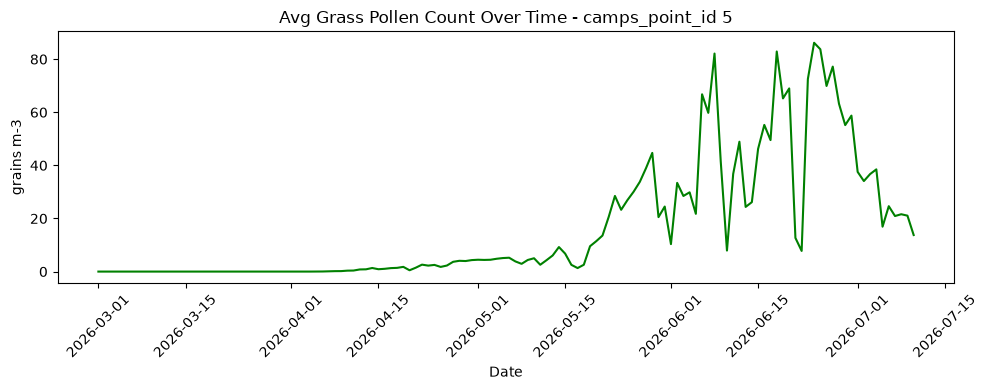

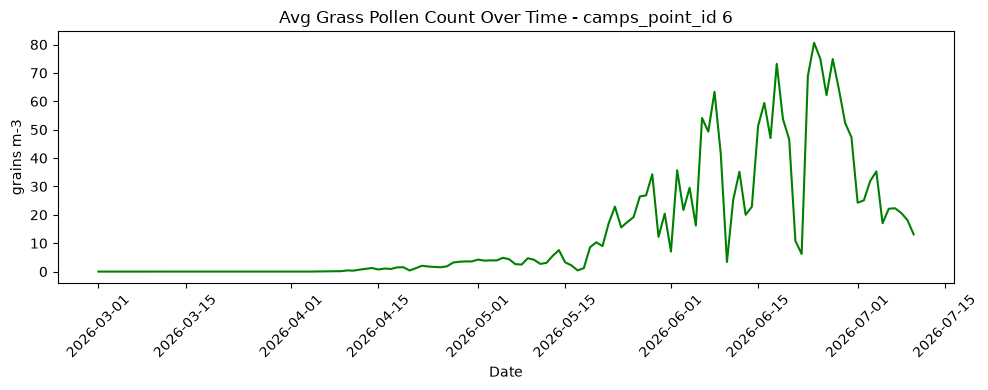

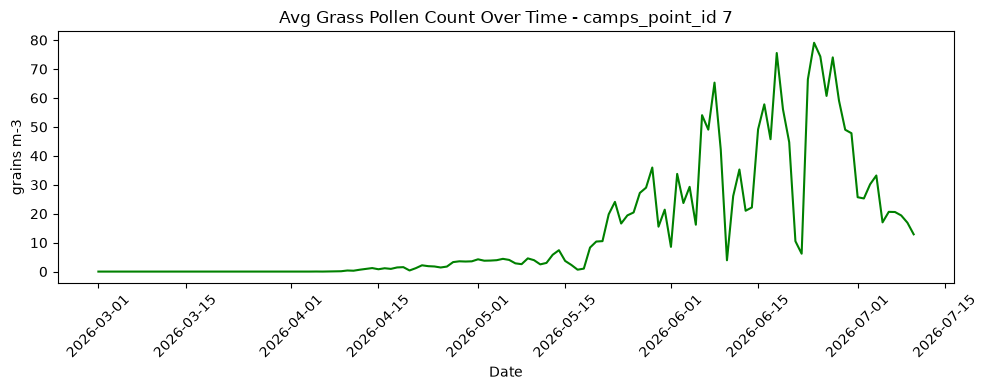

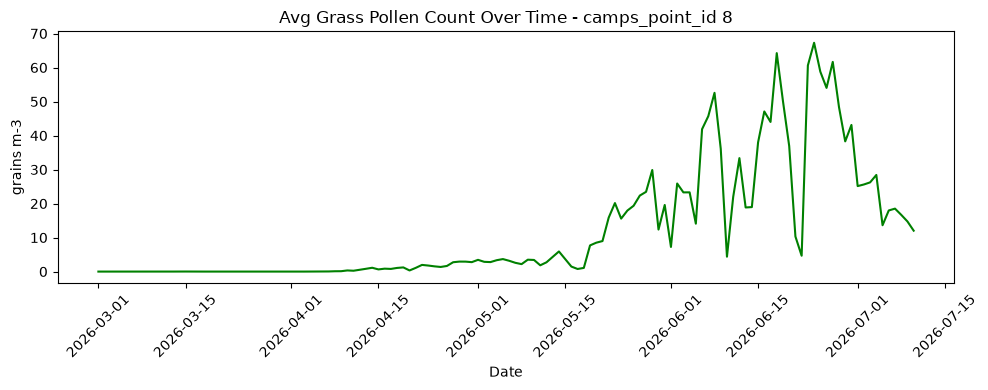

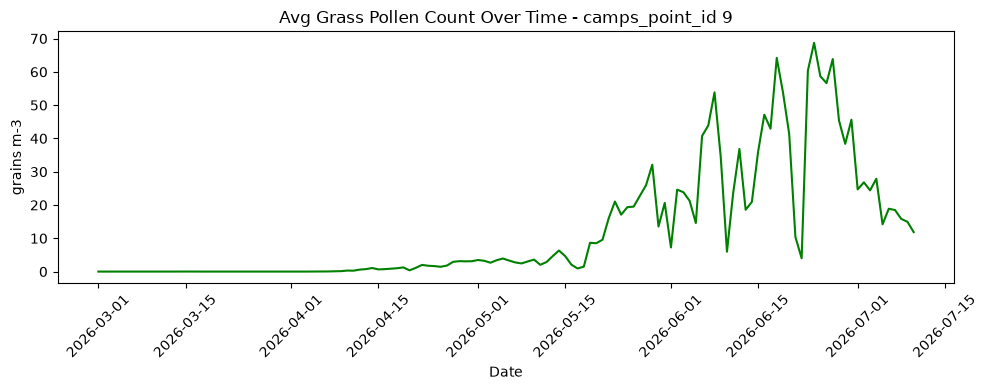

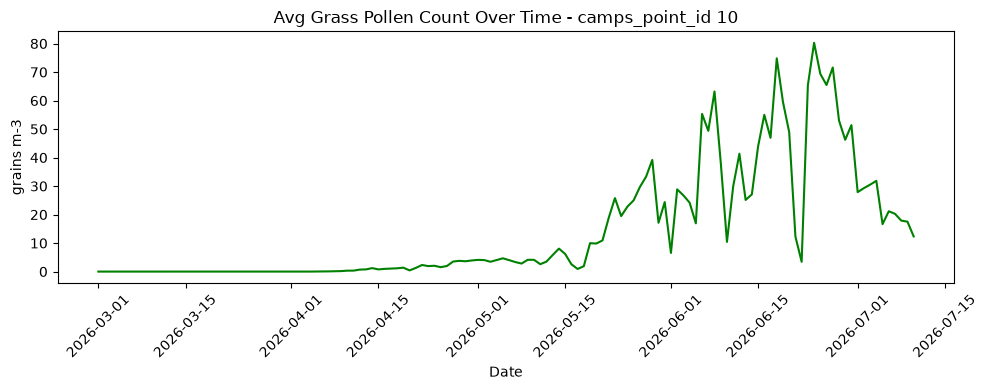

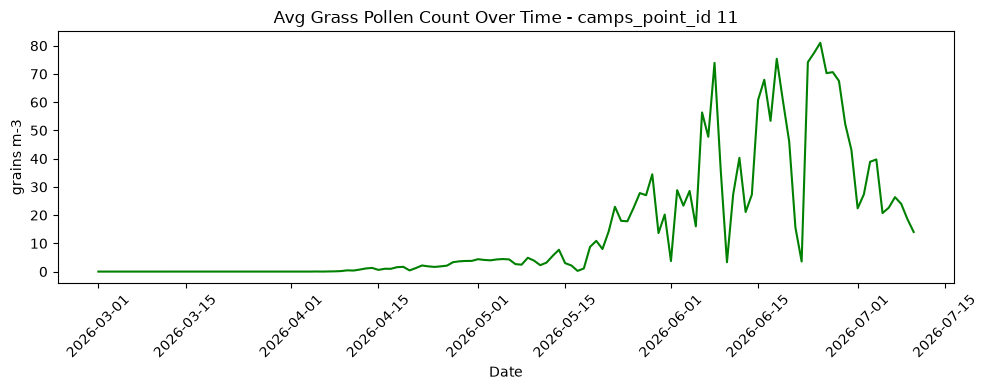

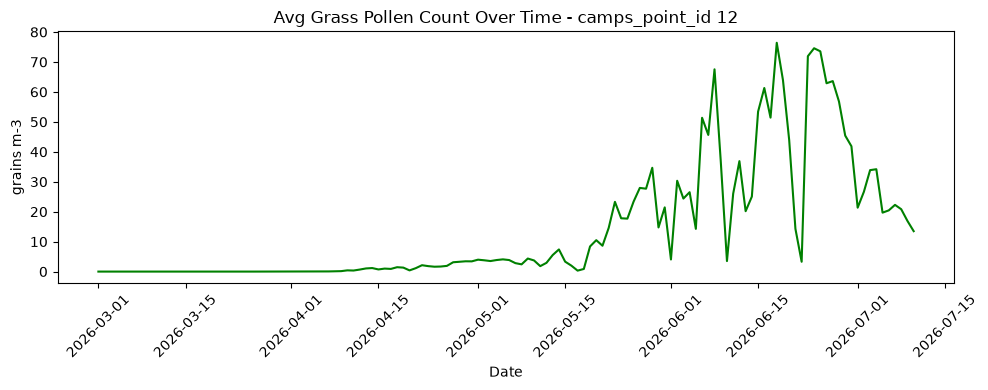

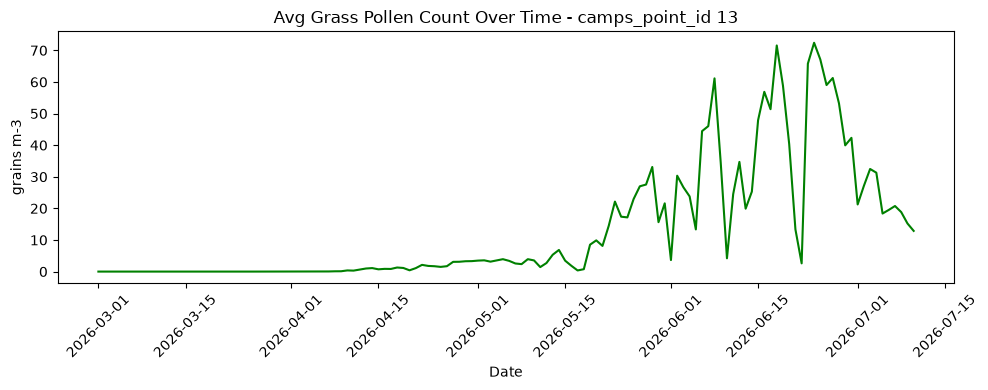

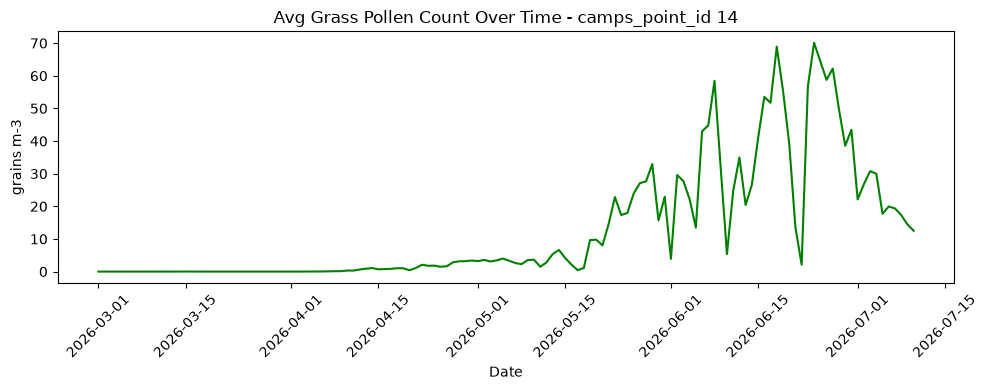

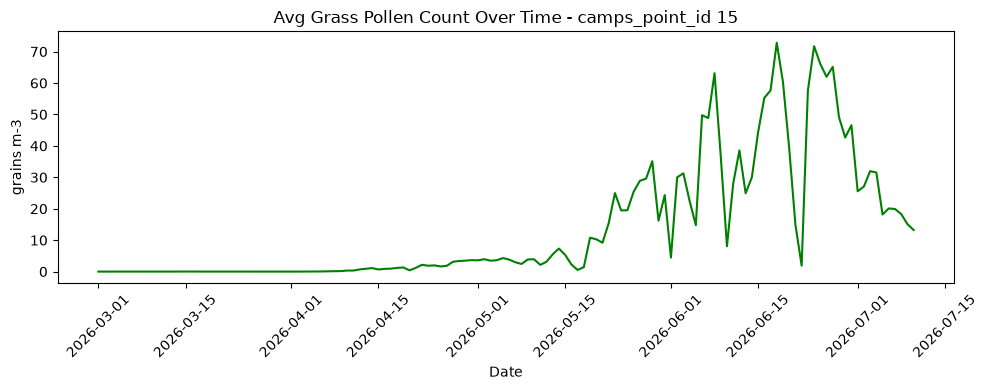

In [23]:
%matplotlib inline

site_ids = sorted(pd.to_numeric(df['camps_point_id'], errors='coerce').dropna().astype(int).unique())

for site_id in site_ids:
    site_series = (
        df_grouped.xs(site_id, level='camps_point_id')['grass_pollen']
        .sort_index()
    )
    plt.figure(figsize=(10, 4))
    plt.plot(site_series.index, site_series.values, color='g')
    plt.title(f"Avg Grass Pollen Count Over Time - camps_point_id {site_id}")
    plt.xlabel("Date")
    plt.xticks(rotation=45)
    plt.ylabel("grains m-3")
    plt.tight_layout()
    plt.show()

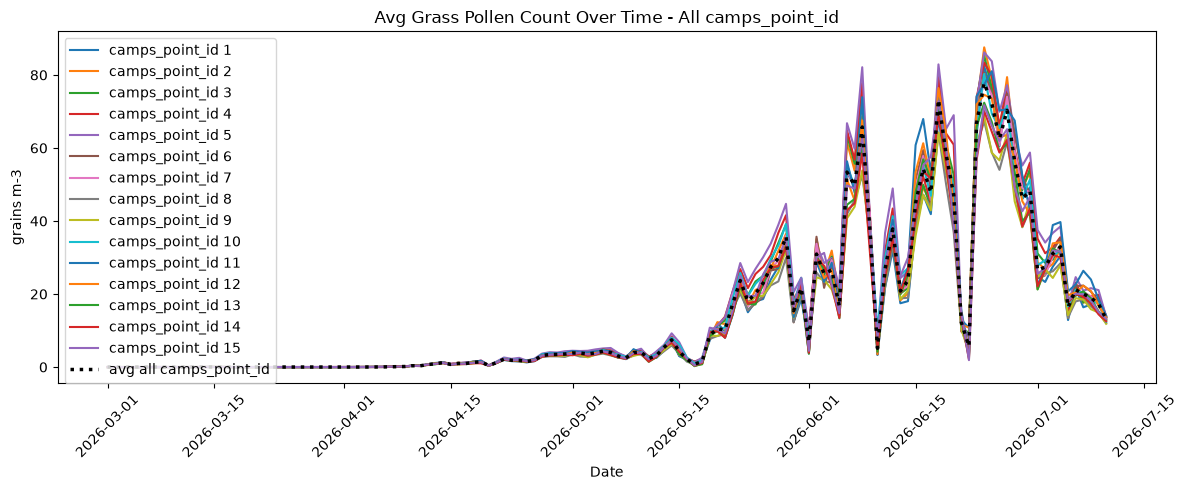

In [29]:
%matplotlib inline

plt.figure(figsize=(12, 5))

overall_avg = (
    df_grouped.groupby(level='fdate')['grass_pollen']
    .mean()
    .sort_index()
)

for site_id in site_ids:
    site_series = (
        df_grouped.xs(site_id, level='camps_point_id')['grass_pollen']
        .sort_index()
    )
    plt.plot(
        site_series.index,
        site_series.values,
        label=f'camps_point_id {site_id}',
        zorder=1
    )

plt.plot(
    overall_avg.index,
    overall_avg.values,
    label='avg all camps_point_id',
    linewidth=2.5,
    color='black',
    linestyle=':',
    zorder=2
)

plt.title('Avg Grass Pollen Count Over Time - All camps_point_id')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.ylabel('grains m-3')
plt.legend(loc='upper left', bbox_to_anchor=(0.0, 1.0))
plt.tight_layout()
plt.show()

In [48]:
df_grouped_time = (
    df.groupby(['fdate', 'ftime'], as_index=False)[
        ['alder_pollen', 'birch_pollen', 'grass_pollen', 'mugwort_pollen', 'olive_pollen', 'ragweed_pollen', 'pollen_total']
    ].mean()
)
df_grouped_time.tail(10)


,fdate,ftime,alder_pollen,birch_pollen,grass_pollen,mugwort_pollen,olive_pollen,ragweed_pollen,pollen_total
3158,2026-07-10,14:00:00,0.0000182629,0.0020141602,14.5385396322,0.2334625244,0.0000000000,0.0000000000,14.7740348180
3159,2026-07-10,15:00:00,0.0000130018,0.0013341268,13.0716695150,0.2490753174,0.0000000000,0.0000000000,13.3220919291
3160,2026-07-10,16:00:00,0.0000089327,0.0012791951,11.2812032064,0.2284070333,0.0000000000,0.0000000000,11.5108982722
3161,2026-07-10,17:00:00,0.0000060399,0.0016110738,11.7185343424,0.2316716512,0.0000000000,0.0000000000,11.9518231074
3162,2026-07-10,18:00:00,0.0000046889,0.0014811198,12.0602600098,0.2343510946,0.0000000000,0.0000000000,12.2960969289
3163,2026-07-10,19:00:00,0.0000036240,0.0012118022,7.6025716146,0.2663019816,0.0000000000,0.0000000000,7.8700892131
3164,2026-07-10,20:00:00,0.0000029882,0.0014854431,6.8975931803,0.2850626628,0.0000000000,0.0000000000,7.1841441472
3165,2026-07-10,21:00:00,0.0000026385,0.0017906189,8.8507405599,0.2936813354,0.0000000000,0.0000000000,9.1462151210
3166,2026-07-10,22:00:00,0.0000024478,0.0011123657,10.0231770833,0.2371236165,0.0000000000,0.0000000000,10.2614152590
3167,2026-07-10,23:00:00,0.0000022570,0.0009872437,10.6445159912,0.2539850871,0.0000000000,0.0000000000,10.8994903564


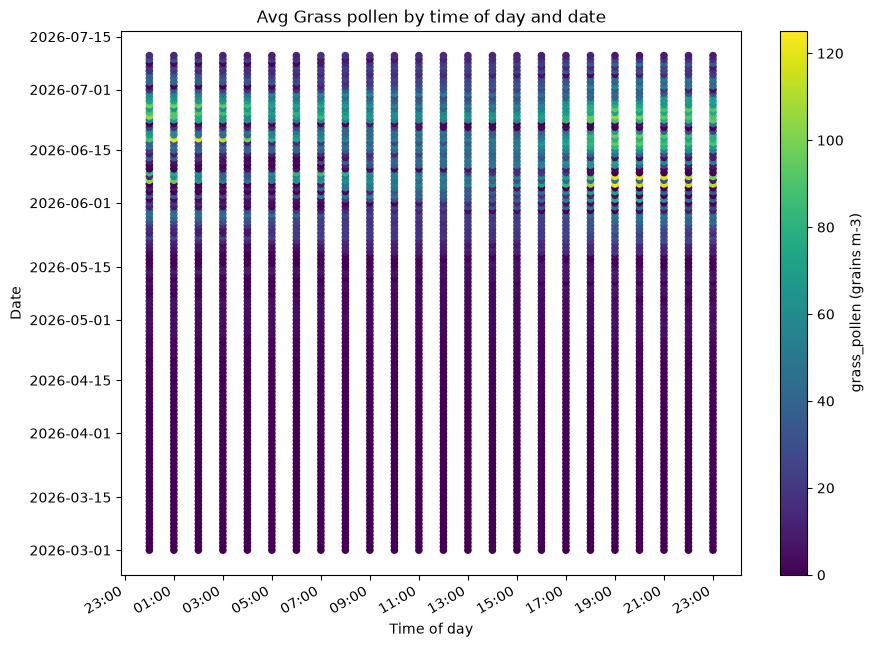

In [55]:
# Scatter plot: x = ftime (time of day), y = fdate (date), color = grass_pollen

ftimes = pd.to_datetime(df_grouped_time['ftime'].astype(str), format='%H:%M:%S', errors='coerce')
fdates = df_grouped_time['fdate']

plt.figure(figsize=(10, 8))
sc = plt.scatter(ftimes, fdates, c=df_grouped_time['grass_pollen'], cmap='viridis', s=20)
plt.colorbar(sc, label='grass_pollen (grains m-3)')
plt.xlabel('Time of day')
plt.ylabel('Date')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.gcf().autofmt_xdate()
plt.title(f'Avg Grass pollen by time of day and date')
plt.show()
